# SHAP Analysis: Global, Local & Stability

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

os.makedirs('shap_output', exist_ok=True)
os.makedirs('shap_analysis', exist_ok=True)

## 1. Load & Setup

In [2]:
df = pd.read_csv('features_final.csv')
df['week_start'] = pd.to_datetime(df['week_start'])
df = df.sort_values(['week_start', 'product_id']).reset_index(drop=True)

pred_df = pd.read_csv('xgb_final_predictions.csv')
pred_df['week_start'] = pd.to_datetime(pred_df['week_start'])

TARGET    = 'sku_sold'
DROP_COLS = ['product_id', 'week_start', 'year', 'week', TARGET]
FEATURES  = [c for c in df.columns if c not in DROP_COLS]

XGB_PARAMS = dict(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, random_state=42, verbosity=0,
)

FOLD_SPLITS = [
    ('2018-02-19', '2019-12-30', '2020-01-06', '2020-03-30'),
    ('2018-02-19', '2020-03-30', '2020-04-06', '2020-06-29'),
    ('2018-02-19', '2020-06-29', '2020-07-06', '2020-09-28'),
    ('2018-02-19', '2020-09-28', '2020-10-05', '2020-12-28'),
]

# Retrain final model on 2018–2020
train_final = df[df['week_start'] <= '2020-12-28']
test_final  = df[(df['week_start'] >= '2021-01-01') & (df['week_start'] <= '2021-12-31')]

final_model = xgb.XGBRegressor(**XGB_PARAMS)
final_model.fit(train_final[FEATURES], train_final[TARGET].values)

# Compute SHAP values for 2021 holdout
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer(test_final[FEATURES])
test_reset  = test_final.reset_index(drop=True)

print(f'Features: {len(FEATURES)}')
print(f'SHAP values shape: {shap_values.values.shape}')

Features: 40
SHAP values shape: (3968, 40)


## 2. Global SHAP — Bar Plot

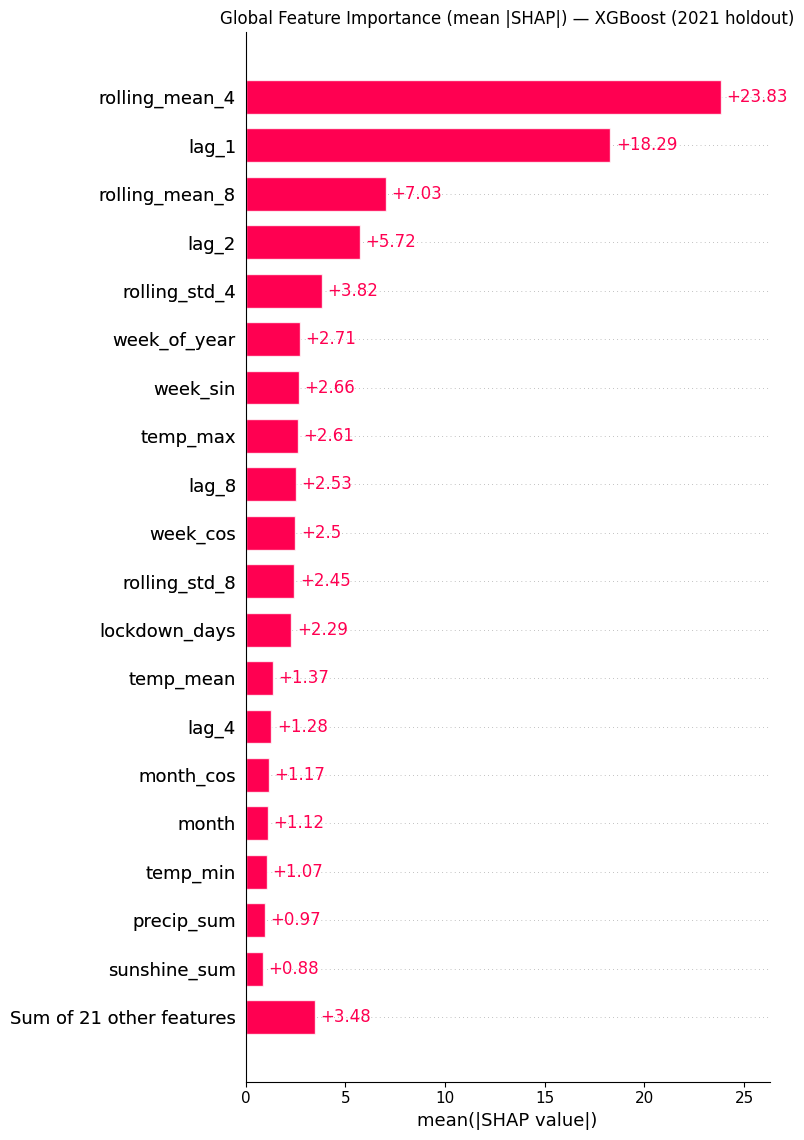

Saved: shap_output/global_bar.png


In [3]:
plt.figure()
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title('Global Feature Importance (mean |SHAP|) — XGBoost (2021 holdout)')
plt.tight_layout()
plt.savefig('shap_output/global_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_output/global_bar.png')

## 3. Local SHAP — Waterfall (3 sample products)

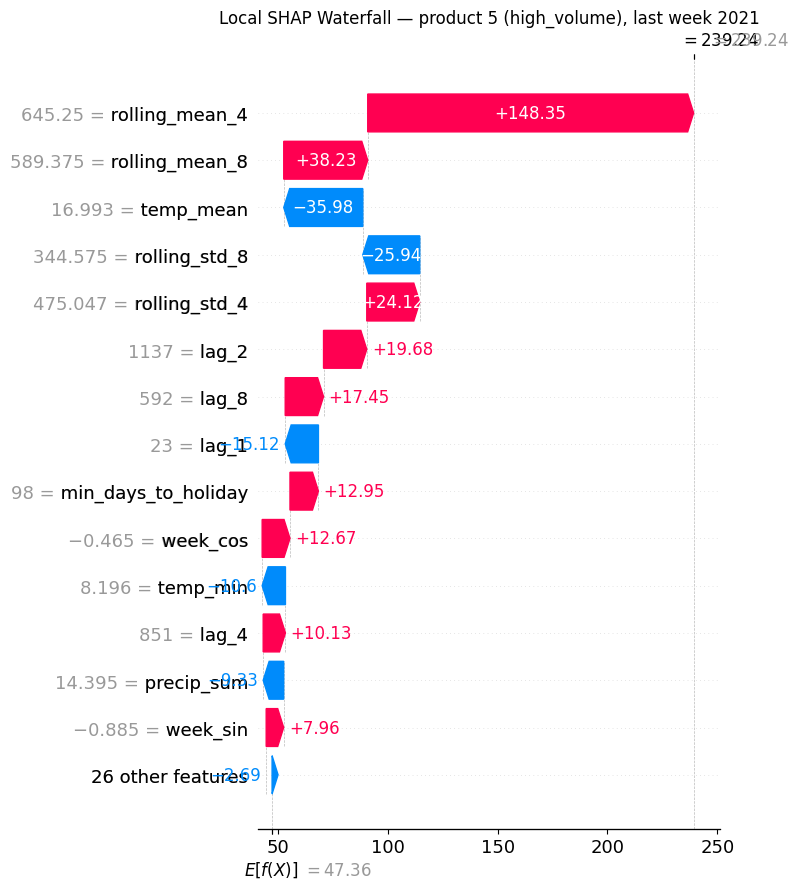

Saved: shap_output/local_waterfall_high_volume_product5.png


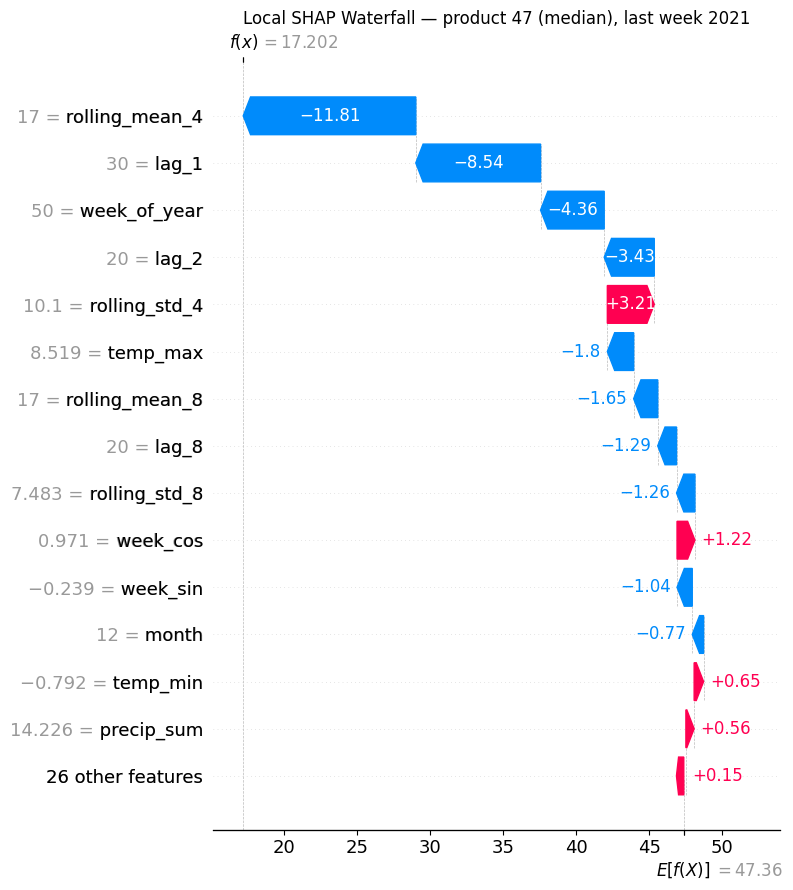

Saved: shap_output/local_waterfall_median_product47.png


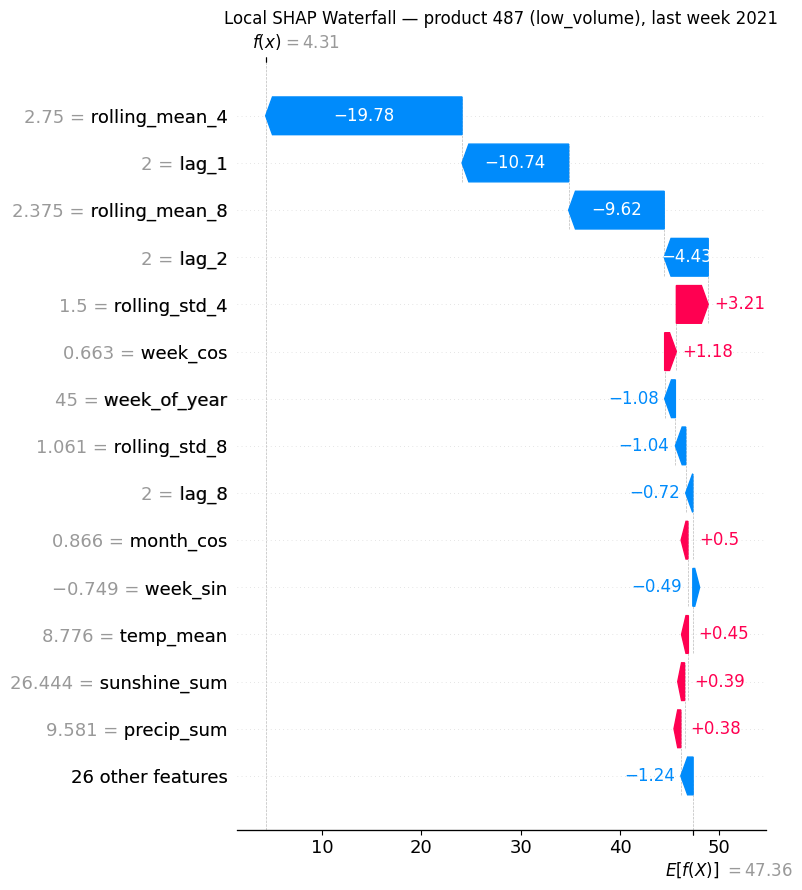

Saved: shap_output/local_waterfall_low_volume_product487.png


In [4]:
product_means = test_final.groupby('product_id')[TARGET].mean()
sorted_means  = product_means.sort_values()

sample_products = {
    'high_volume': sorted_means.index[-1],
    'median':      sorted_means.index[len(sorted_means) // 2],
    'low_volume':  sorted_means.index[0],
}

for label, pid in sample_products.items():
    pid_rows = test_reset[test_reset['product_id'] == pid]
    if pid_rows.empty:
        continue
    row_idx = pid_rows.index[-1]

    plt.figure()
    shap.plots.waterfall(shap_values[row_idx], max_display=15, show=False)
    plt.title(f'Local SHAP Waterfall — product {pid} ({label}), last week 2021')
    plt.tight_layout()
    fname = f'shap_output/local_waterfall_{label}_product{pid}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 4. Stability — Compute SHAP per Fold

In [5]:
fold_shap_means = []
fold_shap_ranks = []
fold_labels     = []

all_splits  = FOLD_SPLITS + [('2018-02-19', '2020-12-28', '2021-01-01', '2021-12-31')]
label_names = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Final 2021']

for label, (tr_start, tr_end, te_start, te_end) in zip(label_names, all_splits):
    train = df[(df['week_start'] >= tr_start) & (df['week_start'] <= tr_end)]
    test  = df[(df['week_start'] >= te_start) & (df['week_start'] <= te_end)]

    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(train[FEATURES], train[TARGET].values)

    sv       = shap.TreeExplainer(model)(test[FEATURES])
    mean_abs = np.abs(sv.values).mean(axis=0)

    fold_shap_means.append(mean_abs)
    fold_shap_ranks.append(
        pd.Series(mean_abs, index=FEATURES).rank(ascending=False).astype(int)
    )
    fold_labels.append(label)
    print(f'{label} done — test rows: {len(test)}')

means_df = pd.DataFrame(fold_shap_means, columns=FEATURES, index=fold_labels)
ranks_df = pd.DataFrame(fold_shap_ranks, index=fold_labels)

Fold 1 done — test rows: 1176
Fold 2 done — test rows: 1110
Fold 3 done — test rows: 904
Fold 4 done — test rows: 872
Final 2021 done — test rows: 3968
